# Plot the current sensor montage

This notebook compares the EEG sensors that the current Eelbrain pipeline actually loads with the complete 61-position montage configured in `pipeline.py`.

In [ ]:
%matplotlib inline

from pathlib import Path

from eelbrain import load_pipeline, plot


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "analysis/trf_pipeline/pipeline.py").is_file():
            return candidate
    raise FileNotFoundError("Could not find analysis/trf_pipeline/pipeline.py")


PROJECT_ROOT = find_project_root()
PIPELINE_DIR = PROJECT_ROOT / "analysis/trf_pipeline"
SUBJECT = "01"

e = load_pipeline(PIPELINE_DIR)

INFO    :  *** AliceComprehension initialized with root /Users/yanyuwoo/Data/bids on 2026-08-19 23:14:41 ***
INFO    :  Using eelbrain 0.43.0a1, mne 1.11.0.


## Sensors currently used by the pipeline

Load one subject through the formal pipeline. This view should contain only the EEG sensors that enter the current analysis.

In [3]:
epochs = e.load_epochs(
    subject=SUBJECT,
    epoch="story-segments",
    raw="0.5-20",
    reference="mastoids",
)
eeg = epochs[0, "eeg"]

configured_names = [str(index) for index in range(1, 62)]
loaded_names = list(eeg.sensor.names)
missing_names = [name for name in configured_names if name not in loaded_names]
unexpected_names = [name for name in loaded_names if name not in configured_names]

print(f"Subject: {SUBJECT}")
print(f"Loaded EEG sensors: {len(loaded_names)}")
print(f"Missing from the 61-position montage: {missing_names}")
print(f"Unexpected EEG sensor names: {unexpected_names}")
print(f"VEOG included: {'VEOG' in loaded_names}")
print(f"AUD included: {'AUD' in loaded_names}")

raw = e.load_raw(subject=SUBJECT, raw="raw")

expected_missing = sorted(
    [name for name in raw.info["bads"] if name in configured_names],
    key=int,
)

assert missing_names == expected_missing
assert "29" in loaded_names

INFO    :  Raw 0.5-20: filtering for /Users/yanyuwoo/Data/bids/sub-01/eeg/sub-01_task-alice_eeg.vhdr...
Subject: 01
Loaded EEG sensors: 54
Missing from the 61-position montage: ['22', '24', '31', '32', '36', '49', '60']
Unexpected EEG sensor names: []
VEOG included: False
AUD included: False


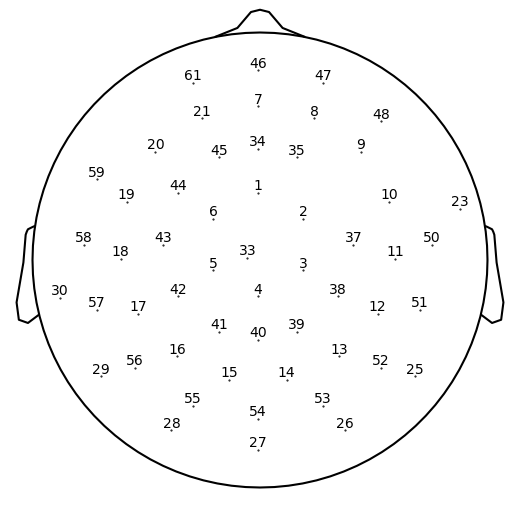

In [4]:
current_sensor_plot = plot.SensorMap(
    eeg,
    labels="name",
    head_radius=True,
)

In [5]:
import numpy as np
import pandas as pd

sensor = eeg.sensor

eelbrain_positions = pd.DataFrame(
    {
        "name": sensor.names,
        "right": np.asarray(sensor.right),
        "anterior": np.asarray(sensor.anterior),
        "superior": np.asarray(sensor.superior),
    }
)

eelbrain_positions["radius"] = np.sqrt(
    eelbrain_positions["right"] ** 2
    + eelbrain_positions["anterior"] ** 2
    + eelbrain_positions["superior"] ** 2
)

eelbrain_positions

,name,right,anterior,superior,radius
0,1,0.000000,0.037124,0.087452,0.095006
1,2,0.032142,0.018557,0.087452,0.095002
2,3,0.032142,-0.018557,0.087452,0.095002
3,4,0.000000,-0.037124,0.087452,0.095006
4,5,-0.032142,-0.018557,0.087452,0.095002
5,6,-0.032142,0.018557,0.087452,0.095002
6,7,0.000000,0.088086,0.035583,0.095001
7,8,0.035825,0.080465,0.035583,0.094996
8,9,0.065455,0.058942,0.035583,0.094998
9,10,0.083769,0.027223,0.035583,0.094997


## Complete montage configured in `pipeline.py`

The `RawSource` montage contains all 61 electrode positions, including channel 29, which is absent from the stored EEG because it was the implicit acquisition reference.

Configured montage positions: 61
Channel 29 configured: True


/var/folders/j8/hc9f3z3931ld2qv6m5zzg0t80000gn/T/ipykernel_24543/504389434.py:5: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  montage.plot(


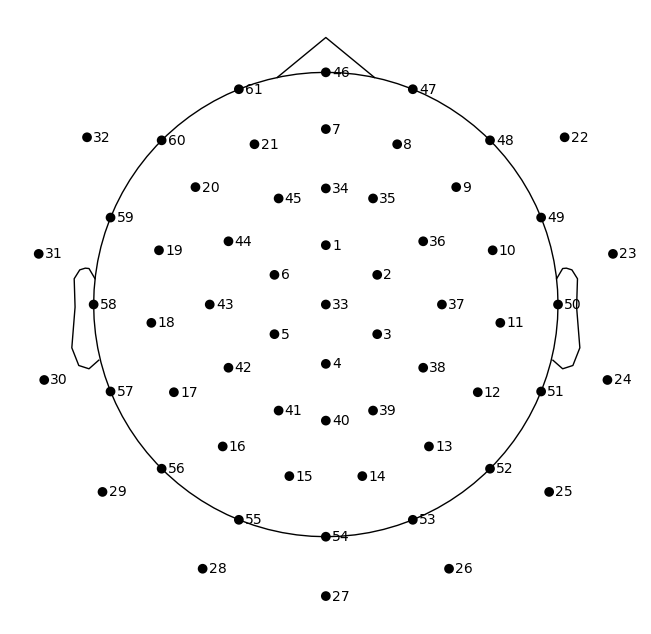

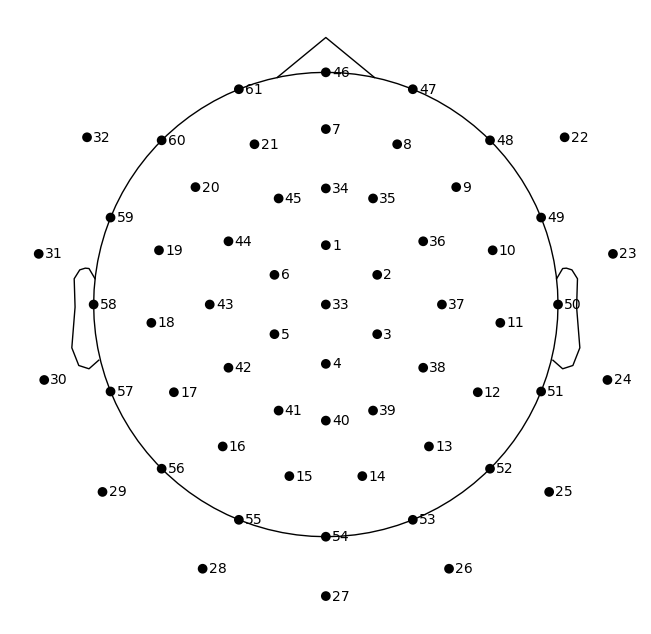

In [ ]:
montage = e.raw["raw"].montage
print(f"Configured montage positions: {len(montage.ch_names)}")
print(f"Channel 29 configured: {'29' in montage.ch_names}")

montage.plot(
    kind="topomap",
    show_names=True,
    sphere="auto",
)

# montage.plot(
#     kind='3d',
#     show_names=True
#     )


In [ ]:
missing_text = ", ".join(f"channel {name}" for name in missing_names) or "None"

print(f"SensorMap: {len(loaded_names)} channels")
print(f"Montage:   {len(montage.ch_names)} positions")
print(f"Missing:   {missing_text}")

SensorMap: 60 channels
Montage:   61 positions
Missing:   channel 29


# Conclusion

- Use channel 25 and 29 to calculate mastoid 